# LSTM Time Series Forecasting -Product Demand Prediction


## 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow version: {tf.__version__}")
print("All libraries loaded.")

TensorFlow version: 2.20.0
All libraries loaded.


## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 3. Data Loading

In [ ]:
DATA_PATH = '/content/drive/MyDrive/data-2025-11-23.csv'
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=['ProductId']).copy()
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %H:%M')
df['ProductId'] = df['ProductId'].astype(int)
df = df.sort_values(['ProductId', 'Date']).reset_index(drop=True)

TARGET = 'TotalQuantity'
TEST_SIZE = 12  # Last 12 months for testing
product_ids = sorted(df['ProductId'].unique())

print(f"Shape: {df.shape}")
print(f"Products ({len(product_ids)}): {product_ids}")
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

Shape: (2116, 12)
Products (20): [np.int64(3), np.int64(7), np.int64(11), np.int64(19), np.int64(22), np.int64(28), np.int64(33), np.int64(40), np.int64(44), np.int64(45), np.int64(47), np.int64(61), np.int64(66), np.int64(71), np.int64(75), np.int64(81), np.int64(86), np.int64(88), np.int64(91), np.int64(93)]
Date range: 2017-01-01 00:00:00 to 2025-10-01 00:00:00


## 5. Feature Engineering

In [ ]:
df['NoOutOfStockEvents_binary'] = (df['NoOutOfStockEvents'] > 0).astype(int)
df['Pandemic_int'] = df['Pandemic'].astype(int)

df['Month'] = df['Date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

df = df.sort_values(['ProductId', 'Date']).reset_index(drop=True)

for lag in [1, 2, 3, 6, 12]:
    df[f'lag_{lag}'] = df.groupby('ProductId')[TARGET].shift(lag)

for w in [3, 6, 12]:
    df[f'rmean_{w}'] = df.groupby('ProductId')[TARGET].transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean()
    )
    df[f'rstd_{w}'] = df.groupby('ProductId')[TARGET].transform(
        lambda x: x.shift(1).rolling(w, min_periods=2).std()
    )

df['diff_1_lagged'] = df.groupby('ProductId')[TARGET].transform(
    lambda x: x.diff(1).shift(1)
)

df['diff_12_lagged'] = df.groupby('ProductId')[TARGET].transform(
    lambda x: x.diff(12).shift(1)
)

df_model = df.dropna().copy()

print(f"\nRows after feature creation: {len(df_model)}")
print("Features created successfully.")

FEATURES = [
    'Price', 'Return', 'NoOutOfStockEvents_binary', 'Pandemic_int',
    'Month', 'month_sin', 'month_cos',
    'lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12',
    'rmean_3', 'rmean_6', 'rmean_12',
    'rstd_3', 'rstd_6', 'rstd_12',
    'diff_1_lagged', 'diff_12_lagged',
]

print(f"\nNumber of features: {len(FEATURES)}")


Rows after feature creation: 1856
Features created successfully.

Number of features: 20


## 6. Temporal Split - CRITICAL (No Data Leakage)

---



In [ ]:

df_model['time_rank'] = df_model.groupby('ProductId').cumcount(ascending=False)
df_train = df_model[df_model['time_rank'] >= TEST_SIZE].copy()
df_test = df_model[df_model['time_rank'] < TEST_SIZE].copy()

print(f"\n{'='*60}")
print("SPLIT VERIFICATION")
print(f"{'='*60}")
print(f"Train samples: {len(df_train)}")
print(f"Test samples:  {len(df_test)}")

for pid in product_ids[:3]:  # Check first 3 products
    train_dates = df_train[df_train['ProductId'] == pid]['Date']
    test_dates = df_test[df_test['ProductId'] == pid]['Date']
    if len(train_dates) > 0 and len(test_dates) > 0:
        print(f"Product {pid}: Train ends {train_dates.max()}, Test starts {test_dates.min()}")
        assert train_dates.max() < test_dates.min(), f"DATA LEAKAGE detected for product {pid}!"

print("✓ Temporal ordering verified - no data leakage")


SPLIT VERIFICATION
Train samples: 1616
Test samples:  240
Product 3: Train ends 2024-10-01 00:00:00, Test starts 2024-11-01 00:00:00
Product 7: Train ends 2024-10-01 00:00:00, Test starts 2024-11-01 00:00:00
Product 11: Train ends 2024-10-01 00:00:00, Test starts 2024-11-01 00:00:00
✓ Temporal ordering verified - no data leakage


## 4. Outlier Capping

In [ ]:
def compute_iqr_bounds(series, factor=1.5):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR

    return lower, upper


def apply_capping(series, lower, upper):
    n = ((series < lower) | (series > upper)).sum()
    capped_series = series.clip(lower=lower, upper=upper)
    return capped_series, n


total_train_capped = 0
total_test_capped = 0

for pid in product_ids:
    train_mask = df_train['ProductId'] == pid
    test_mask = df_test['ProductId'] == pid

    # Use a higher factor for ProductId 19, or a default factor for others
    capping_factor = 3.0 if pid == 19 else 1.5

    lower, upper = compute_iqr_bounds(
        df_train.loc[train_mask, TARGET],
        factor=capping_factor
    )

    df_train.loc[train_mask, TARGET], n_train = apply_capping(
        df_train.loc[train_mask, TARGET],
        lower,
        upper
    )

    df_test.loc[test_mask, TARGET], n_test = apply_capping(
        df_test.loc[test_mask, TARGET],
        lower,
        upper
    )

    if n_train > 0 or n_test > 0:
        print(f"Product {pid}: train capped={n_train}, test capped={n_test}")

    total_train_capped += n_train
    total_test_capped += n_test


print(f"\nTotal train capped: {total_train_capped} / {len(df_train)} "
      f"({total_train_capped / len(df_train) * 100:.1f} %)")

print(f"Total test capped:  {total_test_capped} / {len(df_test)} "
      f"({total_test_capped / len(df_test) * 100:.1f} %)")

Product 7: train capped=3, test capped=0
Product 11: train capped=5, test capped=3
Product 22: train capped=5, test capped=0
Product 28: train capped=1, test capped=0
Product 33: train capped=2, test capped=0
Product 44: train capped=6, test capped=1
Product 45: train capped=4, test capped=0
Product 47: train capped=6, test capped=0
Product 61: train capped=4, test capped=0
Product 66: train capped=1, test capped=3
Product 71: train capped=3, test capped=0
Product 75: train capped=3, test capped=0
Product 81: train capped=5, test capped=0
Product 86: train capped=7, test capped=7
Product 88: train capped=2, test capped=0
Product 91: train capped=4, test capped=0

Total train capped: 61 / 1616 (3.8 %)
Total test capped:  14 / 240 (5.8 %)


## 7. Scaling (Fit ONLY on Training Data)

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_data = df_train[FEATURES].values
scaler.fit(train_data)  # Fit only on training

train_scaled = scaler.transform(train_data)
test_scaled = scaler.transform(df_test[FEATURES].values)

print(f"\nScaled train shape: {train_scaled.shape}")
print(f"Scaled test shape:  {test_scaled.shape}")


Scaled train shape: (1616, 20)
Scaled test shape:  (240, 20)


In [ ]:
#  TARGET SCALING

target_scaler = MinMaxScaler(feature_range=(0, 1))

y_train = df_train[[TARGET]].values
y_test = df_test[[TARGET]].values

target_scaler.fit(y_train)

y_train_scaled = target_scaler.transform(y_train).flatten()
y_test_scaled = target_scaler.transform(y_test).flatten()

## 8. Reshape for LSTM

In [ ]:
X_train = train_scaled.reshape(-1, 1, len(FEATURES))
X_test = test_scaled.reshape(-1, 1, len(FEATURES))

y_train = df_train[TARGET].values
y_test = df_test[TARGET].values

print(f"\nX_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_test shape:  {y_test.shape}")


X_train shape: (1616, 1, 20)
y_train shape: (1616,)
X_test shape:  (240, 1, 20)
y_test shape:  (240,)


## 9. Build LSTM Model

In [ ]:
model = Sequential([
    LSTM(64, input_shape=(1, len(FEATURES)), return_sequences=False),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        21,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,385 (95.25 KB)

 Trainable params: 24,385 (95.25 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Train Model

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_train, y_train_scaled,
    epochs=300,
    batch_size=16,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1,
    shuffle=False
)

print(f"\nTraining completed at epoch {len(history.history['loss'])}")
print(f"Best val_loss: {min(history.history['val_loss']):.6f}")

Epoch 1/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0038 - mae: 0.0571 - val_loss: 1.8965e-04 - val_mae: 0.0142 - learning_rate: 0.0010
Epoch 2/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0021 - mae: 0.0380 - val_loss: 1.8773e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 3/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - mae: 0.0379 - val_loss: 2.2085e-04 - val_mae: 0.0151 - learning_rate: 0.0010
Epoch 4/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0020 - mae: 0.0373 - val_loss: 1.8622e-04 - val_mae: 0.0133 - learning_rate: 0.0010
Epoch 5/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0339 - val_loss: 1.7687e-04 - val_mae: 0.0129 - learning_rate: 0.0010
Epoch 6/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0357 - val_loss: 1.7765e-04 - val_mae: 0.0129 - learning_rate: 0.0010
Epoch 7/300
86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0330 - val_loss: 1.7797e-04 - val_mae: 0.0130 - learni

## 11. Plot Training History

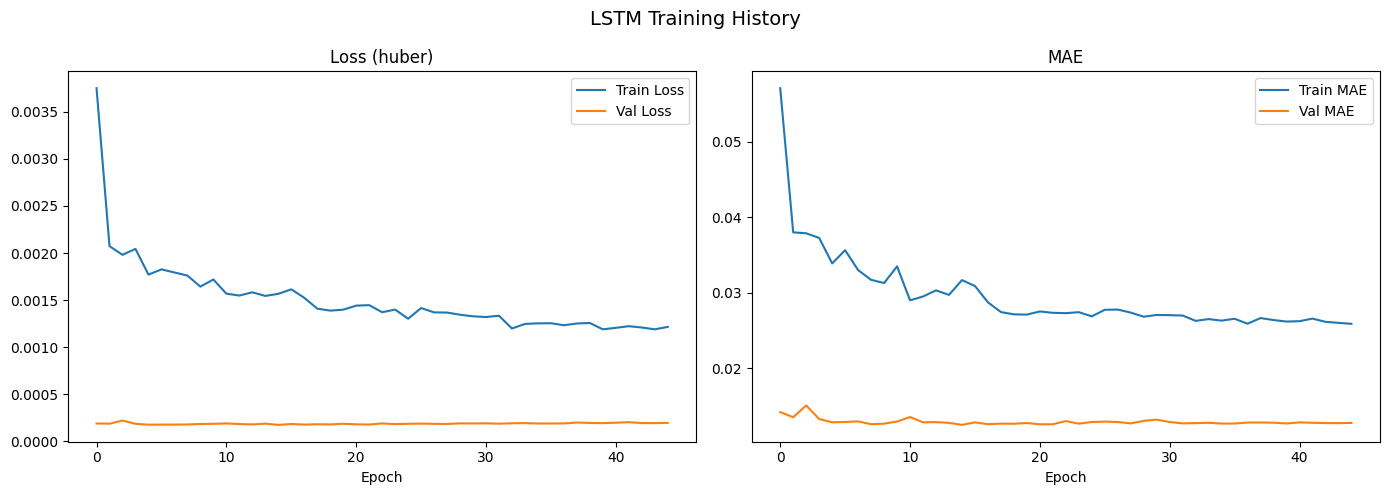

Train loss: 0.001216
Val loss:   0.000196
Ratio:      0.16 (OK)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss (huber)')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MAE')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('LSTM Training History', fontsize=14)
plt.tight_layout()
plt.show()

# Check for overfitting
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
ratio = final_val_loss / final_train_loss
print(f"Train loss: {final_train_loss:.6f}")
print(f"Val loss:   {final_val_loss:.6f}")
print(f"Ratio:      {ratio:.2f} ({'OK' if ratio < 1.5 else 'POSSIBLE OVERFITTING!'})")

## 12. Make Predictions

In [ ]:

pred_scaled = model.predict(X_test, verbose=0).flatten()
fitted_scaled = model.predict(X_train, verbose=0).flatten()

pred_real = np.maximum(
    target_scaler.inverse_transform(pred_scaled.reshape(-1, 1)).flatten(),
    0
)

fitted_real = np.maximum(
    target_scaler.inverse_transform(fitted_scaled.reshape(-1, 1)).flatten(),
    0
)

actual_test_real = np.maximum(
    target_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).flatten(),
    0
)

actual_train_real = np.maximum(
    target_scaler.inverse_transform(y_train_scaled.reshape(-1, 1)).flatten(),
    0
)

print(f"\nPredictions: {len(pred_real)} test, {len(fitted_real)} train")
print(f"Pred range: {pred_real.min():.1f} to {pred_real.max():.1f}")


Predictions: 240 test, 1616 train
Pred range: 39.5 to 2001.5


## 13. Per-Product Results

In [ ]:
def safe_mape(yt, yp):
    m = yt != 0
    if m.sum() == 0:
        return np.nan
    return np.mean(np.abs((yt[m] - yp[m]) / yt[m])) * 100


results = []

for pid in product_ids:
    test_mask = df_test['ProductId'].values == pid

    if test_mask.sum() > 0:
        actual = actual_test_real[test_mask]
        predicted = pred_real[test_mask]

        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt(mean_squared_error(actual, predicted))
        mape = safe_mape(actual, predicted)

        results.append({
            'ProductId': pid,
            'Test_Samples': len(actual),
            'MAE': round(mae, 2),
            'RMSE': round(rmse, 2),
            'MAPE': round(mape, 1) if not np.isnan(mape) else 'N/A',
        })

results_df = pd.DataFrame(results)

print("\n" + "="*60)
print("PER-PRODUCT RESULTS (Out-of-Sample - Last 12 Months)")
print("="*60)
print(results_df.to_string(index=False))


PER-PRODUCT RESULTS (Out-of-Sample - Last 12 Months)
 ProductId  Test_Samples    MAE    RMSE   MAPE
         3            12 193.89  229.66   18.9
         7            12  99.89  110.82   34.3
        11            12  51.59   80.12   13.9
        19            12 914.27 1079.50 1453.3
        22            12 141.90  171.05   28.2
        28            12  34.43   38.27   59.8
        33            12 122.78  153.90   59.5
        40            12 103.18  143.68   25.7
        44            12  23.54   39.99   17.3
        45            12  61.76   74.96   18.8
        47            12  79.09   94.70   13.2
        61            12  58.15   69.88   40.6
        66            12  80.53   95.51   18.5
        71            12  33.24   40.98   50.6
        75            12  83.76  109.37   24.1
        81            12  51.53   59.33   21.9
        86            12  20.60   25.90   18.5
        88            12  21.62   28.34   16.3
        91            12  52.77   63.44   17.5
      

## 14. Global Metrics

In [ ]:
#  GLOBAL METRICS: TRAIN + TEST

all_actual = np.concatenate([actual_train_real, actual_test_real])
all_forecast = np.concatenate([fitted_real, pred_real])

global_mae = mean_absolute_error(all_actual, all_forecast)
global_rmse = np.sqrt(mean_squared_error(all_actual, all_forecast))
r2 = r2_score(all_actual, all_forecast)
correlation = np.corrcoef(all_actual, all_forecast)[0, 1]

print("\n" + "="*60)
print("GLOBAL METRICS (Train + Test Combined)")
print("="*60)
print(f"Total samples: {len(all_actual)}")
print(f"R2 score:      {r2:.6f}")
print(f"Correlation:   {correlation:.6f}")
print(f"MAE:           {global_mae:.4f}")
print(f"RMSE:          {global_rmse:.4f}")


GLOBAL METRICS (Train + Test Combined)
Total samples: 1856
R2 score:      0.699137
Correlation:   0.837480
MAE:           119.0068
RMSE:          241.1362


## 15. Test Set Only Metrics (Most Important)

In [ ]:
#  TEST SET ONLY METRICS

test_mae = mean_absolute_error(actual_test_real, pred_real)
test_rmse = np.sqrt(mean_squared_error(actual_test_real, pred_real))
test_r2 = r2_score(actual_test_real, pred_real)
test_corr = np.corrcoef(actual_test_real, pred_real)[0, 1]
test_mape = safe_mape(actual_test_real, pred_real)

print("\n" + "="*60)
print("TEST SET ONLY METRICS (Out-of-Sample Performance)")
print("="*60)
print(f"Test samples:  {len(actual_test_real)}")
print(f"R2 score:      {test_r2:.6f}")
print(f"Correlation:   {test_corr:.6f}")
print(f"MAE:           {test_mae:.4f}")
print(f"RMSE:          {test_rmse:.4f}")
print(f"MAPE:          {test_mape:.2f}%")


TEST SET ONLY METRICS (Out-of-Sample Performance)
Test samples:  240
R2 score:      0.584452
Correlation:   0.775121
MAE:           115.2601
RMSE:          262.3491
MAPE:          102.11%


## 16. Metrics Excluding Product ID 19



In [ ]:
mask_train_pid19 = df_train['ProductId'].values == 19
mask_test_pid19 = df_test['ProductId'].values == 19

actual_train_no_pid19 = actual_train_real[~mask_train_pid19]
fitted_real_no_pid19 = fitted_real[~mask_train_pid19]

actual_test_no_pid19 = actual_test_real[~mask_test_pid19]
pred_real_no_pid19 = pred_real[~mask_test_pid19]


#  GLOBAL METRICS (Excluding Product ID 19)

all_actual_no_pid19 = np.concatenate([actual_train_no_pid19, actual_test_no_pid19])
all_forecast_no_pid19 = np.concatenate([fitted_real_no_pid19, pred_real_no_pid19])

global_mae_no_pid19 = mean_absolute_error(all_actual_no_pid19, all_forecast_no_pid19)
global_rmse_no_pid19 = np.sqrt(mean_squared_error(all_actual_no_pid19, all_forecast_no_pid19))
r2_no_pid19 = r2_score(all_actual_no_pid19, all_forecast_no_pid19)
correlation_no_pid19 = np.corrcoef(all_actual_no_pid19, all_forecast_no_pid19)[0, 1]

print("\n" + "="*60)
print("GLOBAL METRICS (Train + Test Combined, Excluding Product ID 19)")
print("="*60)
print(f"Total samples (excl. PID 19): {len(all_actual_no_pid19)}")
print(f"R2 score:                   {r2_no_pid19:.6f}")
print(f"Correlation:                {correlation_no_pid19:.6f}")
print(f"MAE:                        {global_mae_no_pid19:.4f}")
print(f"RMSE:                       {global_rmse_no_pid19:.4f}")

#  TEST SET ONLY METRICS (Excluding Product ID 19)

test_mae_no_pid19 = mean_absolute_error(actual_test_no_pid19, pred_real_no_pid19)
test_rmse_no_pid19 = np.sqrt(mean_squared_error(actual_test_no_pid19, pred_real_no_pid19))
test_r2_no_pid19 = r2_score(actual_test_no_pid19, pred_real_no_pid19)
test_corr_no_pid19 = np.corrcoef(actual_test_no_pid19, pred_real_no_pid19)[0, 1]
test_mape_no_pid19 = safe_mape(actual_test_no_pid19, pred_real_no_pid19)

print("\n" + "="*60)
print("TEST SET ONLY METRICS (Out-of-Sample, Excluding Product ID 19)")
print("="*60)
print(f"Test samples (excl. PID 19):  {len(actual_test_no_pid19)}")
print(f"R2 score:                     {test_r2_no_pid19:.6f}")
print(f"Correlation:                  {test_corr_no_pid19:.6f}")
print(f"MAE:                          {test_mae_no_pid19:.4f}")
print(f"RMSE:                         {test_rmse_no_pid19:.4f}")
print(f"MAPE:                         {test_mape_no_pid19:.2f}%")


GLOBAL METRICS (Train + Test Combined, Excluding Product ID 19)
Total samples (excl. PID 19): 1763
R2 score:                   0.747270
Correlation:                0.865512
MAE:                        88.9830
RMSE:                       137.7408

TEST SET ONLY METRICS (Out-of-Sample, Excluding Product ID 19)
Test samples (excl. PID 19):  228
R2 score:                     0.792413
Correlation:                  0.891511
MAE:                          73.2067
RMSE:                         105.4341
MAPE:                         31.00%


### 16. Residual Analysis and Outlier Detection


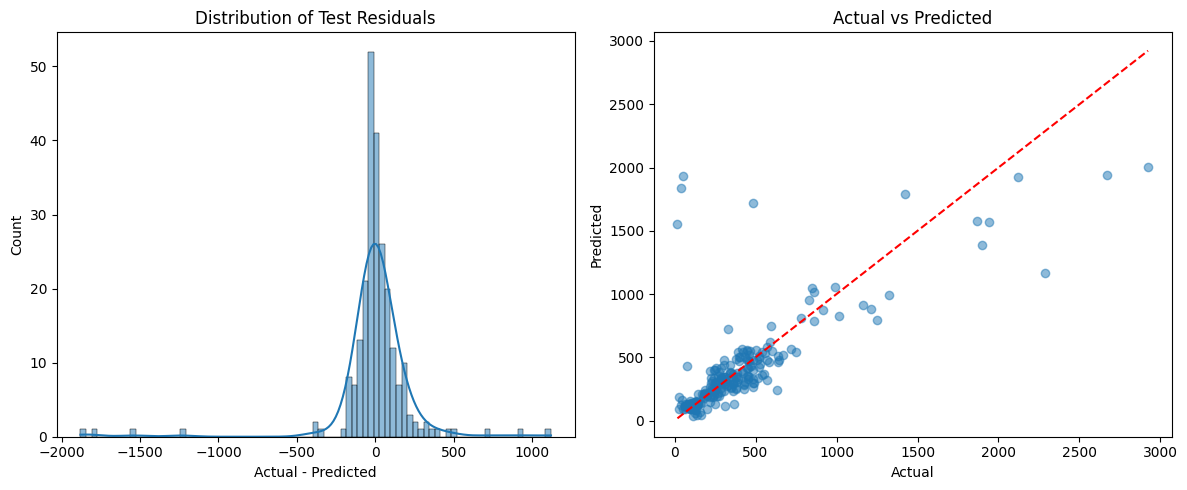

,ProductId,Test_Samples,MAE,RMSE,MAPE,MAE_Contribution
3,19,12,914.27,1079.50,1453.3,45.7135
0,3,12,193.89,229.66,18.9,9.6945
4,22,12,141.90,171.05,28.2,7.0950
6,33,12,122.78,153.90,59.5,6.1390
7,40,12,103.18,143.68,25.7,5.1590
1,7,12,99.89,110.82,34.3,4.9945
14,75,12,83.76,109.37,24.1,4.1880
12,66,12,80.53,95.51,18.5,4.0265
10,47,12,79.09,94.70,13.2,3.9545
19,93,12,76.68,108.91,91.5,3.8340


In [ ]:
import seaborn as sns

residuals = actual_test_real - pred_real

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title('Distribution of Test Residuals')
plt.xlabel('Actual - Predicted')

plt.subplot(1, 2, 2)
plt.scatter(actual_test_real, pred_real, alpha=0.5)
plt.plot([actual_test_real.min(), actual_test_real.max()], [actual_test_real.min(), actual_test_real.max()], 'r--')
plt.title('Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

results_df['MAE_Contribution'] = (results_df['MAE'] * results_df['Test_Samples']) / len(actual_test_real)
display(results_df.sort_values(by='MAE_Contribution', ascending=False))

## 17. Plot Forecasts

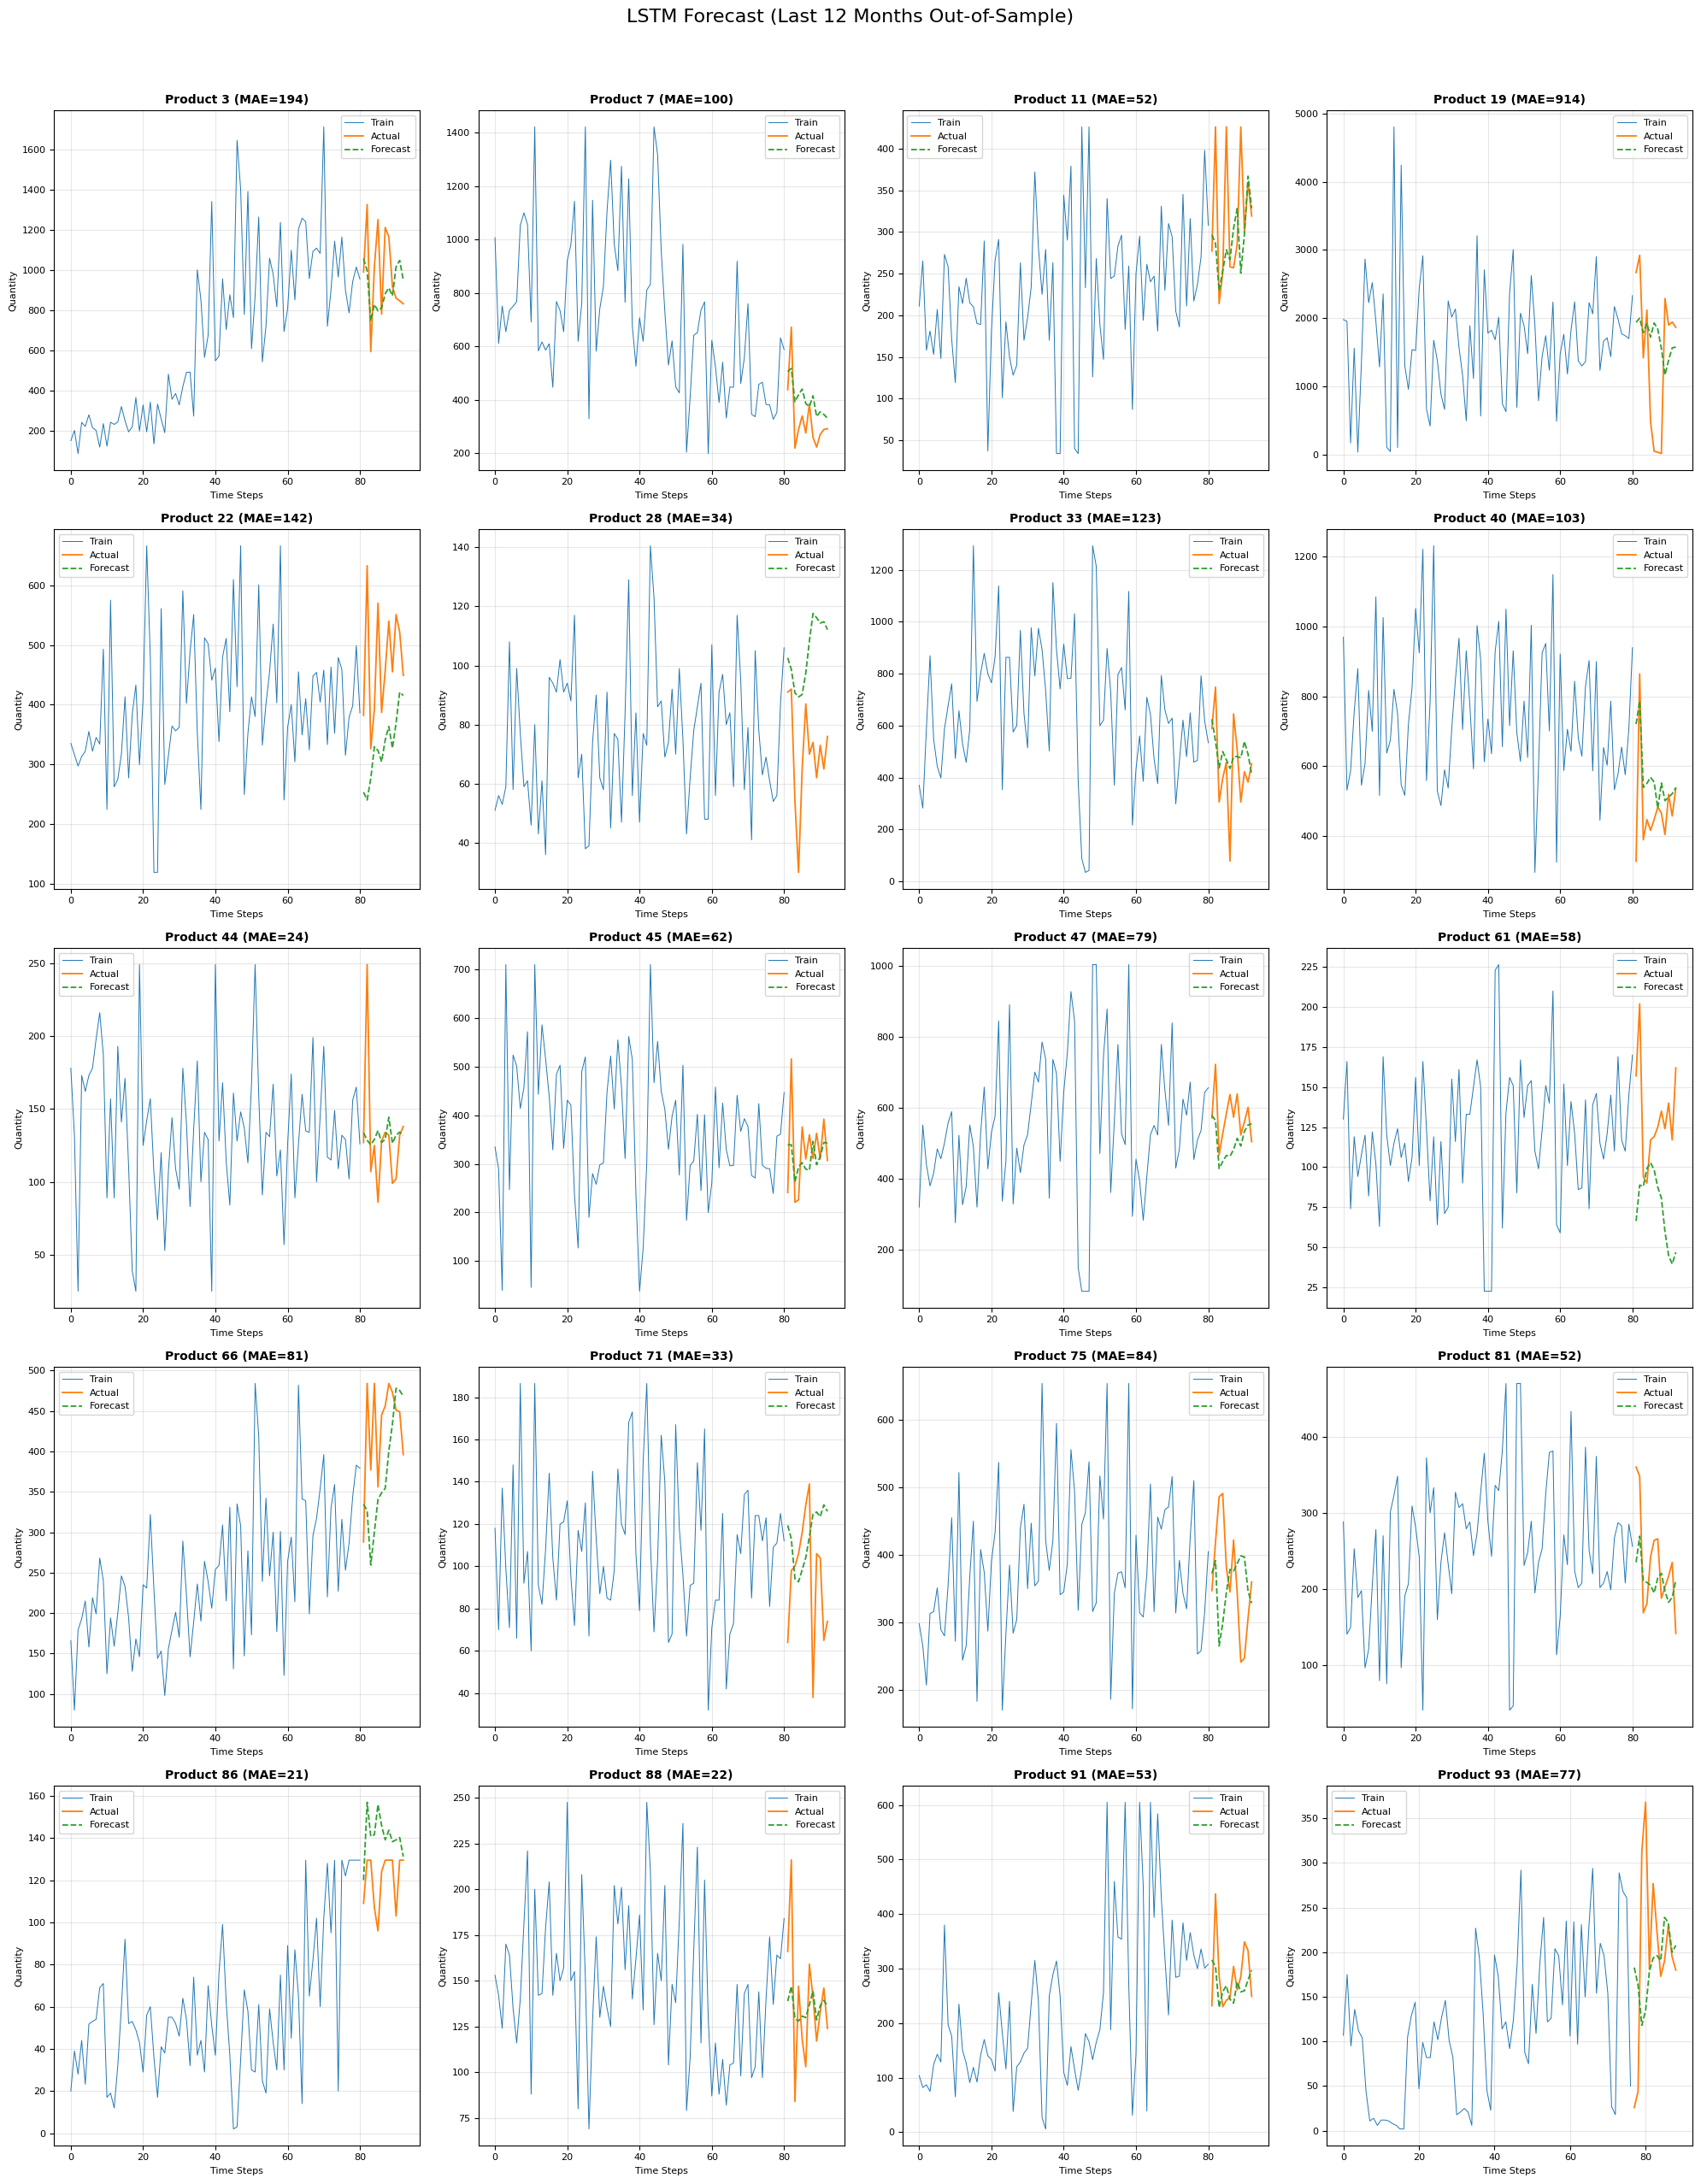

In [ ]:
#  PLOT FORECASTS

n_products = len(product_ids)
n_rows = (n_products + 3) // 4

fig, axes = plt.subplots(n_rows, 4, figsize=(20, 5*n_rows))
axes = np.array(axes).flatten()

for i, pid in enumerate(product_ids):
    ax = axes[i]

    train_product_mask = df_train['ProductId'] == pid
    test_product_mask = df_test['ProductId'] == pid

    train_actual = actual_train_real[train_product_mask.values]
    test_actual = actual_test_real[test_product_mask.values]
    test_pred = pred_real[test_product_mask.values]

    if len(test_actual) > 0:
        ax.plot(range(len(train_actual)), train_actual, lw=0.7, label='Train')

        test_start = len(train_actual)
        test_end = test_start + len(test_actual)

        ax.plot(range(test_start, test_end), test_actual, lw=1.3, label='Actual')
        ax.plot(range(test_start, test_end), test_pred, '--', lw=1.3, label='Forecast')

        mae = mean_absolute_error(test_actual, test_pred)
        ax.set_title(f'Product {pid} (MAE={mae:.0f})', fontsize=10, fontweight='bold')
    else:
        ax.plot(range(len(train_actual)), train_actual, lw=0.7, label='Train')
        ax.set_title(f'Product {pid} (No test data)', fontsize=10)

    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.set_xlabel('Time Steps', fontsize=8)
    ax.set_ylabel('Quantity', fontsize=8)

for i in range(len(product_ids), len(axes)):
    axes[i].set_visible(False)

plt.suptitle('LSTM Forecast (Last 12 Months Out-of-Sample)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Detailed Forecast Plot for Product ID 19

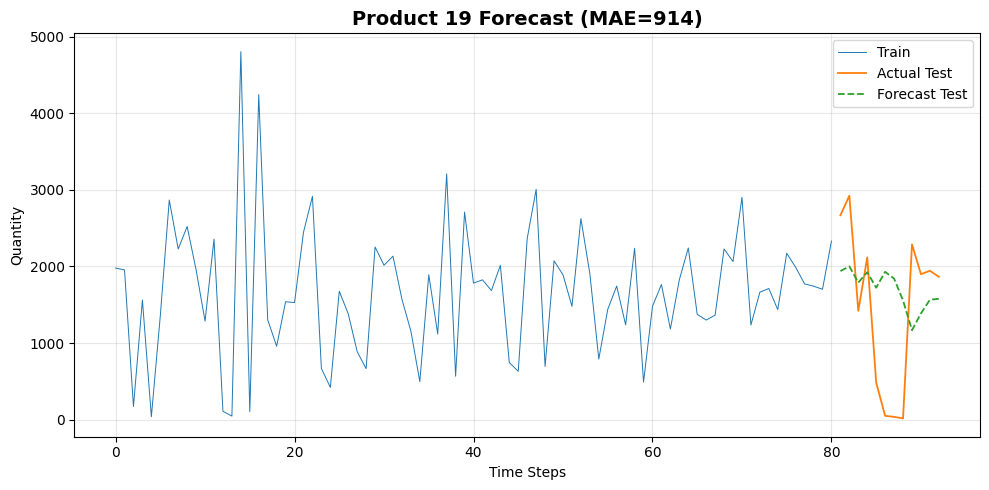

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

pid_to_plot = 19

train_product_mask = df_train['ProductId'] == pid_to_plot
test_product_mask = df_test['ProductId'] == pid_to_plot

train_actual = actual_train_real[train_product_mask.values]
test_actual = actual_test_real[test_product_mask.values]
test_pred = pred_real[test_product_mask.values]

ax.plot(range(len(train_actual)), train_actual, lw=0.7, label='Train')

test_start = len(train_actual)
test_end = test_start + len(test_actual)

ax.plot(range(test_start, test_end), test_actual, lw=1.3, label='Actual Test')
ax.plot(range(test_start, test_end), test_pred, '--', lw=1.3, label='Forecast Test')

mae = mean_absolute_error(test_actual, test_pred)
ax.set_title(f'Product {pid_to_plot} Forecast (MAE={mae:.0f})', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel('Time Steps', fontsize=10)
ax.set_ylabel('Quantity', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import random

random.seed(42)

os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['PYTHONHASHSEED'] = '0'

print("Additional seeds and environment variables set for reproducibility.")


Additional seeds and environment variables set for reproducibility.
